# J-lens vs logit lens on Qwen3.5-9B — pretrained lens summary

**Question.** On Qwen3.5-9B, does the pre-fitted Jacobian lens retrieve the annotated
intermediates and answer targets of `data/evaluations` better than the logit lens read off
the same activations? How do the two lenses behave layer by layer and on held-out text?

**Answer (this run).** **Mostly yes, but the margin is small.** Pooled over all 542 items with a supported intermediate, the J-lens
retrieves it in the top 10 at some inner block for **0.359** of items against **0.320** for the logit lens
(J − logit **+0.039**, 95% CI [+0.008, +0.070]; AUC over k +0.031 [+0.010, +0.051]). The gain is
task-dependent:

* **J-lens better:** multihop (+0.113 [+0.030, +0.196]), multilingual (+0.085 [+0.051, +0.116]), and
  association (+0.059 [+0.020, +0.108]). On association both lenses are near zero.
* **Tie:** order-ops (−0.009) and poetry (+0.010). Typo leans towards the logit lens (−0.042 [−0.156, +0.083]).
  Order-ops is not specific: controls (numbers from another item) also hit at 0.46–0.49.
* **Answer targets:** J-lens slightly better, 0.894 vs 0.862 @10 (+0.032 [+0.005, +0.064]), mostly on multihop.
* **Held-out text:** the J-lens is a *worse* next-token predictor than the logit lens. It has higher KL to the
  model below ~60% depth (10–17 vs ~7 nats), lower top-1 agreement at every depth, and much lower entropy.
* **Chinese:** the logit lens's top-1 is a Chinese token for up to 46% of items at block 23. It is CJK at some
  inner block for 82–100% of items in every dataset. For the J-lens, at most 8% of top-1s per block are CJK.
  Chinese tokens are left as is and count as misses, so part of the J-lens lead may be that it reads out English
  where the logit lens reads out Chinese. A run with translated aliases will separate the two.

Run: bf16 on an RTX A6000, 551 prompts, about 13 min for the task pass and 22 min for 256 held-out passages.

This notebook follows `notebooks/jacobian_lens/pretrained_lens_summary.ipynb` (same strict
scoring, same four views, Figures 52/55/56 adaptations) for the **instruct** checkpoint
`Qwen/Qwen3.5-9B` and the lens `bcywinski/jacobian-lens-qwen3.5-9b/lens_n1000.pt`. It adds a
benchmark table with paired bootstrap intervals, per-layer retrieval curves, and per-layer
readouts. **Nothing is fitted.**

**Chinese tokens are left as they are.** Qwen often reads concepts out as Chinese tokens
(`意大利` for *Italy*). Labels are scored **English only**, exactly as annotated, so a Chinese
spelling counts as a miss; readout tables below print Chinese tokens verbatim, untranslated.
A run with translated aliases is deliberately left for later.

## Method

* **Lenses.** `lens_l(h) = unembed(J_l h)` with `J_l = E[∂h_final / ∂h_l]`; the logit lens is
  the same readout with `J_l = I`. Both are read off **one shared forward** per batch
  (`jlens.batched_evaluation.evaluate_paired_batched`): prompts are length-grouped, right
  padded with an attention mask, and read at each row's last real token.
* **Prompts.** Raw text, whitespace preserved, no chat template, no BOS (Qwen has none).
  Readout: last prompt token, except poetry's last newline token.
* **Scoring** (`jlens.strict_scoring.DecodedSpellings`). A word's accepted token IDs are the
  complete decoded vocabulary tokens equal to the word as-is/lower/capitalised, with zero or one
  leading space (order-ops also accepts digit/word and operation synonyms). No prefix
  fallback. Words without such a token are *unsupported* and excluded, not counted as misses.
  Ranks are 1-based over the full vocabulary, minimised over accepted IDs.
* **Retrieval@K.** A supported word hits if its best rank over the **inner blocks** 0–30 is
  ≤ K (K = 10); the final block is the shared model output and is excluded. Hits are averaged
  within an item, then across items.
* **AUC.** Area under retrieval@k against log k for k ∈ {1, 2, 5, 10, 20, 50, 100}, normalised
  so that always-rank-1 scores 1 (as in Figure 52, but inner blocks only for the benchmark).
* **Uncertainty.** J − logit differences get 95% intervals from a paired bootstrap over items
  (2000 resamples).
* **Held-out text** (Figures 55/56). Paragraphs from the WikiText-103 **test** split; the lens
  was fitted on WikiText-103 training text, so the passages are not fitting data.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_DIR = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "batched_evaluation.py").is_file()),
    None,
)
if REPO_DIR is None:
    raise RuntimeError("Open this notebook from a checkout of the repository.")
sys.path.insert(0, str(REPO_DIR))

import hashlib
import json
import pickle
import re
import subprocess
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from huggingface_hub import hf_hub_download
from IPython.display import display
from transformers import AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens.batched_evaluation import (
    evaluate_distributions_batched,
    evaluate_paired_batched,
)
from jlens.evaluation import DATASETS, load_eval
from jlens.metrics import lens_vector_geometry
from jlens.reference_plots import (
    SWEEP_KS,
    intermediate_rank_sweep,
    plot_distribution_summary,
    plot_intermediate_sweep,
    plot_lens_comparison,
)
from jlens.strict_scoring import DecodedSpellings, ExplicitPromptModel
from jlens.summaries import (
    answer_counts,
    plot_retrieval_summary,
    retrieval_summary,
    target_final_counts,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)
LENSES = ["logit lens", "J-lens"]
COLORS = {"J-lens": "tab:blue", "logit lens": "tab:purple"}

In [2]:
MODEL_ID = os.environ.get("JLENS_MODEL_ID", "Qwen/Qwen3.5-9B")
MODEL_REVISION = None  # None = the snapshot already in HF_HOME; the resolved commit is recorded below.
LENS_REPO, LENS_FILE = "bcywinski/jacobian-lens-qwen3.5-9b", "lens_n1000.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = getattr(torch, os.environ.get("JLENS_DTYPE", "bfloat16"))  # as in qwen35_9b_mid_generation
BOS_POLICY = "none"  # Qwen has no BOS token
K = 10
KS = SWEEP_KS  # (1, 2, 5, 10, 20, 50, 100)
N_BOOT = 2000
BATCH_OPTIONS = dict(
    batch_size=8, max_batch_tokens=2048, max_seq_len=512,
    position_chunk_size=8, rank_chunk_size=8, batching="auto",
)
# Held-out passages for Figures 55/56: whole WikiText-103 test paragraphs (no truncation)
# of HELD_OUT_TOKENS[0]..HELD_OUT_TOKENS[1] tokens, the first HELD_OUT_N in corpus order.
HELD_OUT_N = 256
HELD_OUT_TOKENS = (64, 128)
HELD_OUT_OPTIONS = dict(
    batch_size=8, max_batch_tokens=1024, max_seq_len=128,
    position_chunk_size=4, batching="auto",
)
GEOMETRY_VOCAB_CHUNK_SIZE = 1024
SLUG = MODEL_ID.split("/")[-1].lower()
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", REPO_DIR / "runs" / f"{SLUG}-lens-summary"))
RUN_DIR.mkdir(parents=True, exist_ok=True)
REFRESH = False  # True recomputes every cached step below

### Load the model and the pretrained lens

The lens must cover every inner block 0 … n_layers−2 with finite d_model × d_model
Jacobians; any stored final-block Jacobian is dropped, so both lenses share the model output
at the last block.

In [3]:
def file_sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, revision=MODEL_REVISION, dtype=DTYPE)
hf_model = hf_model.to(DEVICE).eval()
assert hf_model.dtype == DTYPE, f"loaded {hf_model.dtype}, requested {DTYPE}"
adapter = jlens.from_hf(hf_model, tokenizer, compile=False, force_bos=False)
model = ExplicitPromptModel(adapter, bos_policy=BOS_POLICY)

lens_path = hf_hub_download(LENS_REPO, LENS_FILE)
lens_sha256 = file_sha256(lens_path)
stored = jlens.JacobianLens.load(lens_path)
INNER = list(range(model.n_layers - 1))
assert stored.d_model == model.d_model, "lens/model residual widths differ"
assert set(INNER) <= set(stored.source_layers), "lens is missing inner blocks"
for layer in INNER:
    matrix = stored.jacobians[layer]
    assert matrix.shape == (model.d_model, model.d_model) and torch.isfinite(matrix).all(), layer
lens = jlens.JacobianLens(
    {layer: stored.jacobians[layer] for layer in INNER},
    n_prompts=stored.n_prompts, d_model=stored.d_model,
)
del stored, matrix
VOCAB_SIZE = hf_model.get_output_embeddings().weight.shape[0]
spellings = DecodedSpellings(tokenizer, vocab_size=VOCAB_SIZE)
print(adapter, "|", lens)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

HFLensModel(Qwen3_5ForCausalLM, n_layers=32, d_model=4096) | JacobianLens(d_model=4096, n_prompts=1000, source_layers=[0..30] (31 layers))


In [4]:
def fingerprint(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, ensure_ascii=False, default=str).encode()).hexdigest()


def source_hashes(*modules):
    """Hash jlens sources so local edits invalidate the caches."""
    return {name: file_sha256(REPO_DIR / "jlens" / f"{name}.py") for name in modules}


try:
    repo_commit = subprocess.check_output(["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"], text=True).strip()
except (OSError, subprocess.CalledProcessError):
    repo_commit = None

# Recorded with the results, per AGENTS.md's Experiment Configuration.
RUN_INFO = {
    "model_id": MODEL_ID, "model_commit": getattr(hf_model.config, "_commit_hash", None),
    "dtype": str(hf_model.dtype), "device": DEVICE,
    "gpu": torch.cuda.get_device_name() if DEVICE == "cuda" else None,
    "n_layers": model.n_layers, "d_model": model.d_model, "vocab_size": VOCAB_SIZE,
    "lens": f"{LENS_REPO}/{LENS_FILE}", "lens_sha256": lens_sha256, "lens_n_prompts": lens.n_prompts,
    "lens_corpus": "Salesforce/wikitext wikitext-103-raw-v1 (train), 1000 x 128 tokens",
    "prompt_format": "raw text, whitespace preserved, no chat template, no BOS",
    "labels": "English as annotated; Chinese spellings not accepted, no translated aliases",
    "scoring": "decoded whole-token spellings, full-vocabulary ranks, inner blocks",
    "batch": BATCH_OPTIONS, "torch": torch.__version__, "transformers": transformers.__version__,
    "repo_commit": repo_commit,
    "source": source_hashes("hf", "readout", "strict_scoring", "lens", "hooks", "batched_evaluation",
                            "evaluation", "metrics"),
}
(RUN_DIR / "run_info.json").write_text(json.dumps(RUN_INFO, indent=1))
CACHE_KEY = {k: v for k, v in RUN_INFO.items() if k not in {"gpu", "repo_commit"}}


def cached(name, settings, compute):
    """Pickle `compute()` under RUN_DIR, keyed by the run configuration and `settings`."""
    path = RUN_DIR / f"{name}-{fingerprint([CACHE_KEY, settings])[:16]}.pkl"
    if path.is_file() and not REFRESH:
        print(f"cache hit: {path.name}")
        return pd.read_pickle(path)
    value = compute()
    fd, tmp = tempfile.mkstemp(dir=RUN_DIR, suffix=".tmp")
    with os.fdopen(fd, "wb") as handle:
        pickle.dump(value, handle)
    Path(tmp).replace(path)
    print(f"cache saved: {path.name}")
    return value


RUN_INFO

{'model_id': 'Qwen/Qwen3.5-9B',
 'model_commit': None,
 'dtype': 'torch.bfloat16',
 'device': 'cuda',
 'gpu': 'NVIDIA RTX A6000',
 'n_layers': 32,
 'd_model': 4096,
 'vocab_size': 248320,
 'lens': 'bcywinski/jacobian-lens-qwen3.5-9b/lens_n1000.pt',
 'lens_sha256': '25f7c003432b44f01b94a45a32322a4994186aad9110060a463392806a6525ba',
 'lens_n_prompts': 1000,
 'lens_corpus': 'Salesforce/wikitext wikitext-103-raw-v1 (train), 1000 x 128 tokens',
 'prompt_format': 'raw text, whitespace preserved, no chat template, no BOS',
 'labels': 'English as annotated; Chinese spellings not accepted, no translated aliases',
 'scoring': 'decoded whole-token spellings, full-vocabulary ranks, inner blocks',
 'batch': {'batch_size': 8,
  'max_batch_tokens': 2048,
  'max_seq_len': 512,
  'position_chunk_size': 8,
  'rank_chunk_size': 8,
  'batching': 'auto'},
 'torch': '2.12.0+cu130',
 'transformers': '5.9.0',
 'repo_commit': 'd929c2e6cbacea44bc8ac83cd267b224777916f9',
 'source': {'hf': '3fbd0caa63a75f44d41f2c

## 1. Task pass and correct-answer counts

Six prompt sets from `data/evaluations`. One batched pass scores both lenses at every block.
“Correct” means the model's next-token argmax is an accepted spelling of the annotated target
(a lexical next-token match, not generated-answer accuracy). Unsupported (no whole-token
spelling) and unannotated targets are counted separately, never as incorrect.

In [5]:
evals = {name: load_eval(str(REPO_DIR), name) for name in DATASETS}
all_words, items = cached(
    "tasks", {"evals": evals, "batch": BATCH_OPTIONS},
    lambda: evaluate_paired_batched(
        model, lens, evals, spelling_lookup=spellings,
        preserve_prompt_whitespace=True, **BATCH_OPTIONS,
    ),
)
display(items.attrs.get("evaluation", {}))
correct_counts = answer_counts(items, datasets=DATASETS)
display(correct_counts.style.format({"supported_accuracy": "{:.1%}"}, na_rep="N/A"))

cache hit: tasks-a0dd90581f5abb60.pkl


{'batching': 'padded',
 'n_model_passes': 69,
 'n_items': 551,
 'batch_sizes': [8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  8,
  7],
 'batch_size': 8,
 'max_batch_tokens': 2048,
 'max_seq_len': 512,
 'position_chunk_size': 8,
 'rank_chunk_size': 8,
 'bos_policy': 'none'}

,dataset,total,annotated,supported,correct,incorrect,unsupported,unannotated,supported_accuracy
0,multihop,93,93,86,28,58,7,0,32.6%
1,multilingual,107,107,79,18,61,28,0,22.8%
2,order-ops,55,55,53,14,39,2,0,26.4%
3,poetry,98,0,0,0,0,0,98,N/A
4,association,102,0,0,0,0,0,102,N/A
5,typo,96,0,0,0,0,0,96,N/A


In [6]:
coverage = (
    all_words[all_words["lens"].eq("J-lens")]
    .groupby(["dataset", "kind"])["single_token"].agg(["sum", "count"])
    .rename(columns={"sum": "supported", "count": "annotated"})
    .unstack("kind")
)
print("Whole-token coverage of the annotated words (supported / annotated):")
display(coverage)

Whole-token coverage of the annotated words (supported / annotated):


supported                     annotated                    
kind           control intermediate target   control intermediate target
dataset                                                                 
association      102.0        102.0    NaN     102.0        102.0    NaN
multihop          92.0         94.0   86.0     101.0        103.0   93.0
multilingual     418.0        426.0   79.0     420.0        428.0  107.0
order-ops         83.0        109.0   53.0      84.0        110.0   55.0
poetry            98.0         98.0    NaN      98.0         98.0    NaN
typo              96.0         96.0    NaN      96.0         96.0    NaN

## 2. Intermediate retrieval: all items vs correct-only

Each supported intermediate hits if **any inner block** ranks it ≤ K. “All” is every item with
a supported intermediate; “correct-only” keeps items whose target the model predicts. N/A
means no eligible items, not zero.

,dataset,lens,subset,score,n_items_subset,n_items_used,n_items_excluded,n_words_total,n_words_used,n_words_excluded,word_coverage
0,multihop,logit lens,all,0.405,93,84,9,103,94,9,0.913
1,multihop,logit lens,correct,0.750,28,28,0,28,28,0,1.000
2,multihop,J-lens,all,0.518,93,84,9,103,94,9,0.913
3,multihop,J-lens,correct,0.821,28,28,0,28,28,0,1.000
4,multilingual,logit lens,all,0.384,107,107,0,428,426,2,0.995
5,multilingual,logit lens,correct,0.347,18,18,0,72,72,0,1.000
6,multilingual,J-lens,all,0.469,107,107,0,428,426,2,0.995
7,multilingual,J-lens,correct,0.458,18,18,0,72,72,0,1.000
8,order-ops,logit lens,all,0.700,55,55,0,110,109,1,0.991
9,order-ops,logit lens,correct,0.714,14,14,0,28,27,1,0.964


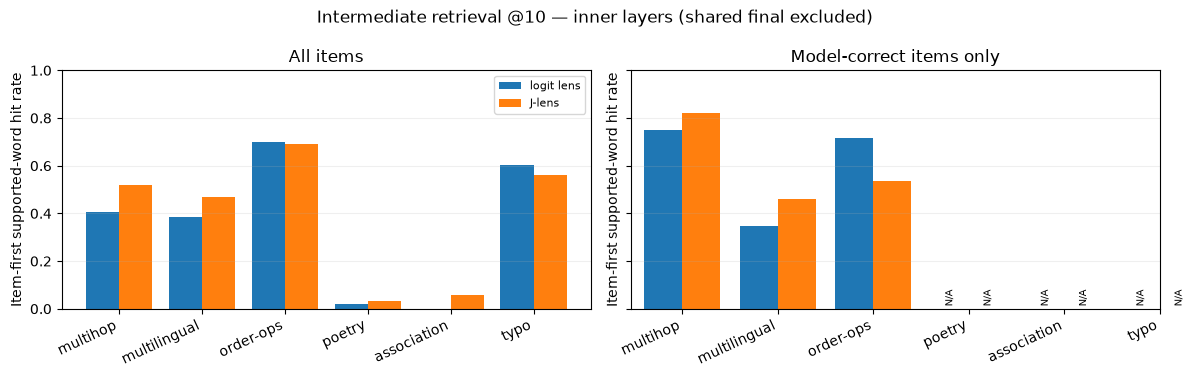

In [7]:
intermediate = retrieval_summary(
    all_words, items, kind="intermediate", k=K, layer_scope="inner",
    subsets=("all", "correct"), datasets=DATASETS,
)
coverage_columns = [
    "dataset", "lens", "subset", "score", "n_items_subset", "n_items_used",
    "n_items_excluded", "n_words_total", "n_words_used", "n_words_excluded", "word_coverage",
]
display(intermediate[coverage_columns].style.format(na_rep="N/A", precision=3))
fig, axes = plot_retrieval_summary(intermediate)
plt.show()
plt.close(fig)

## 3. Annotated answer-target retrieval

Best inner-block retrieval@K of the annotated **answer target** for each lens (multihop,
multilingual, order-ops carry targets). Separately, the target's hit rate at the shared final
model output @1/@K — identical for both lenses by construction.

,dataset,lens,subset,score,n_items_subset,n_items_used,n_items_excluded,n_words_total,n_words_used,n_words_excluded,word_coverage
0,multihop,logit lens,all,0.802,93,86,7,93,86,7,0.925
1,multihop,J-lens,all,0.837,93,86,7,93,86,7,0.925
2,multilingual,logit lens,all,0.899,107,79,28,107,79,28,0.738
3,multilingual,J-lens,all,0.911,107,79,28,107,79,28,0.738
4,order-ops,logit lens,all,0.906,55,53,2,55,53,2,0.964
5,order-ops,J-lens,all,0.962,55,53,2,55,53,2,0.964
6,poetry,logit lens,all,N/A,98,0,98,0,0,0,N/A
7,poetry,J-lens,all,N/A,98,0,98,0,0,0,N/A
8,association,logit lens,all,N/A,102,0,102,0,0,0,N/A
9,association,J-lens,all,N/A,102,0,102,0,0,0,N/A


,annotated,supported,unsupported,unannotated,shared_output_target@1,shared_output_target@10
dataset,,,,,,
multihop,93,86,7,0,0.326,0.686
multilingual,107,79,28,0,0.228,0.342
order-ops,55,53,2,0,0.264,0.491
poetry,0,0,0,98,N/A,N/A
association,0,0,0,102,N/A,N/A
typo,0,0,0,96,N/A,N/A


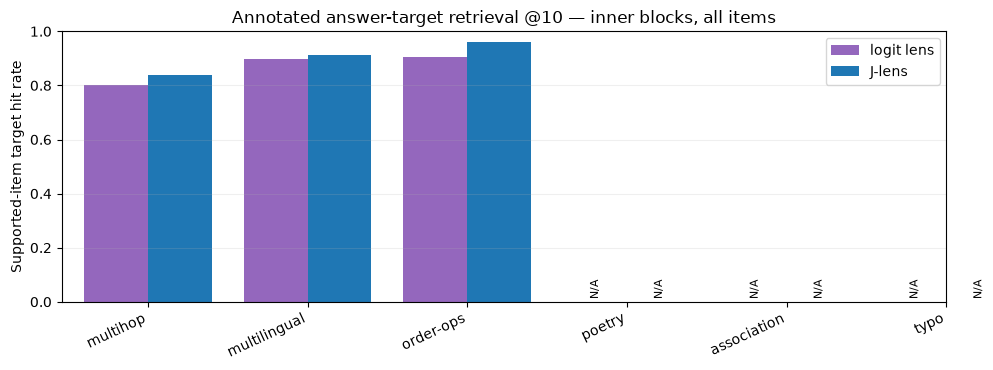

In [8]:
answer_targets = retrieval_summary(
    all_words, items, kind="target", k=K, layer_scope="inner",
    subsets=("all",), datasets=DATASETS,
)
final_targets = target_final_counts(all_words, items, k=K, datasets=DATASETS)
display(answer_targets[coverage_columns].style.format(na_rep="N/A", precision=3))
shared_final = final_targets.pivot(index="dataset", columns="k", values="hit_rate")
shared_final.columns = [f"shared_output_target@{cutoff}" for cutoff in shared_final.columns]
shared_final = correct_counts.set_index("dataset")[
    ["annotated", "supported", "unsupported", "unannotated"]
].join(shared_final).reindex(DATASETS)
display(shared_final.style.format(na_rep="N/A", precision=3))

fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(DATASETS))
width = 0.8 / len(LENSES)
for index, name in enumerate(LENSES):
    scores = answer_targets[answer_targets["lens"].eq(name)].set_index("dataset")["score"].reindex(DATASETS)
    positions = x - 0.4 + width * (index + 0.5)
    ax.bar(positions, scores, width, label=name, color=COLORS[name])
    for position, score in zip(positions, scores, strict=True):
        if pd.isna(score):
            ax.text(position, 0.02, "N/A", ha="center", fontsize=8, rotation=90)
ax.set_xticks(x, DATASETS, rotation=25, ha="right")
ax.set(ylim=(0, 1), ylabel="Supported-item target hit rate",
       title=f"Annotated answer-target retrieval @{K} — inner blocks, all items")
ax.grid(axis="y", alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

## 4. Benchmark: J-lens vs logit lens

One row per dataset plus all items pooled. Item-level scores (hit@K, AUC over k, both over
inner blocks) for supported words; Δ = J − logit with a paired item bootstrap 95% interval.
Controls are the intermediates of another item of the same dataset (`items[(i + n//2) % n]`),
the chance level of a lens that surfaces any on-topic word.

In [9]:
def item_scores(kind):
    """Per (dataset, item, lens): mean hit@K and AUC over KS of supported words, inner blocks."""
    words = all_words[all_words["kind"].eq(kind) & all_words["single_token"].eq(True)]
    best = np.array([np.asarray(r)[:-1].min() for r in words["ranks"]])
    hits = pd.DataFrame(best[:, None] <= np.asarray(KS)[None, :], index=words.index, columns=KS)
    per_item = hits.join(words[["dataset", "item", "lens"]]).groupby(["dataset", "item", "lens"]).mean()
    log_k = np.log(KS)
    scores = per_item.to_numpy(float)
    auc = (np.diff(log_k) * (scores[:, :-1] + scores[:, 1:]) / 2).sum(1) / (log_k[-1] - log_k[0])
    return pd.DataFrame({"hit": per_item[K].astype(float), "auc": auc}, index=per_item.index)


def paired_bootstrap(diff, n=N_BOOT, seed=0):
    rng = np.random.default_rng(seed)
    means = diff[rng.integers(0, len(diff), (n, len(diff)))].mean(1)
    return np.percentile(means, [2.5, 97.5])


def benchmark(kind, metric):
    wide = item_scores(kind)[metric].unstack("lens")
    rows = []
    for dataset in [*DATASETS, "pooled"]:
        group = wide if dataset == "pooled" else wide.loc[[dataset]] if dataset in wide.index else wide.iloc[:0]
        group = group.dropna()
        if group.empty:
            rows.append(dict(dataset=dataset, n_items=0))
            continue
        diff = (group["J-lens"] - group["logit lens"]).to_numpy()
        low, high = paired_bootstrap(diff)
        rows.append({"dataset": dataset, "n_items": len(group), "logit lens": group["logit lens"].mean(),
                     "J-lens": group["J-lens"].mean(), "J − logit": diff.mean(), "CI low": low, "CI high": high})
    return pd.DataFrame(rows).set_index("dataset")


bench = {
    (f"intermediate hit@{K}"): benchmark("intermediate", "hit"),
    "intermediate AUC": benchmark("intermediate", "auc"),
    (f"control hit@{K}"): benchmark("control", "hit"),
    (f"target hit@{K}"): benchmark("target", "hit"),
    "target AUC": benchmark("target", "auc"),
}
for name, table in bench.items():
    print(name)
    display(table.style.format(precision=3, na_rep="N/A").format({"n_items": "{:.0f}"}))

intermediate hit@10


,n_items,logit lens,J-lens,J − logit,CI low,CI high
dataset,,,,,,
multihop,84,0.404762,0.517857,0.113095,0.029762,0.196429
multilingual,107,0.383956,0.468847,0.084891,0.051402,0.116044
order-ops,55,0.700000,0.690909,-0.009091,-0.109091,0.090909
poetry,98,0.020408,0.030612,0.010204,-0.020408,0.051020
association,102,0.000000,0.058824,0.058824,0.019608,0.107843
typo,96,0.604167,0.562500,-0.041667,-0.156250,0.083333
pooled,542,0.320264,0.359164,0.038899,0.007991,0.069657


intermediate AUC


,n_items,logit lens,J-lens,J − logit,CI low,CI high
dataset,,,,,,
multihop,84,0.446638,0.541560,0.094922,0.057199,0.131609
multilingual,107,0.382703,0.452396,0.069693,0.045905,0.093643
order-ops,55,0.662441,0.664981,0.002540,-0.041790,0.047565
poetry,98,0.022465,0.055628,0.033163,0.011740,0.059200
association,102,0.035314,0.087022,0.051708,0.019608,0.086735
typo,96,0.617692,0.544523,-0.073169,-0.165072,0.019550
pooled,542,0.332109,0.363604,0.031495,0.010318,0.051243


control hit@10


,n_items,logit lens,J-lens,J − logit,CI low,CI high
dataset,,,,,,
multihop,83,0.024096,0.054217,0.030120,0.006024,0.066265
multilingual,107,0.002336,0.010903,0.008567,0.000000,0.019470
order-ops,50,0.490000,0.460000,-0.030000,-0.140000,0.080000
poetry,98,0.000000,0.000000,0.000000,0.000000,0.000000
association,102,0.000000,0.009804,0.009804,0.000000,0.029412
typo,96,0.000000,0.000000,0.000000,0.000000,0.000000
pooled,536,0.049907,0.055348,0.005442,-0.006374,0.017568


target hit@10


,n_items,logit lens,J-lens,J − logit,CI low,CI high
dataset,,,,,,
multihop,86,0.802326,0.837209,0.034884,-0.023256,0.093023
multilingual,79,0.898734,0.911392,0.012658,0.000000,0.037975
order-ops,53,0.905660,0.962264,0.056604,0.000000,0.132075
poetry,0,nan,nan,nan,nan,nan
association,0,nan,nan,nan,nan,nan
typo,0,nan,nan,nan,nan,nan
pooled,218,0.862385,0.894495,0.032110,0.004587,0.064220


target AUC


,n_items,logit lens,J-lens,J − logit,CI low,CI high
dataset,,,,,,
multihop,86,0.782822,0.848214,0.065392,0.033385,0.100311
multilingual,79,0.858176,0.853138,-0.005037,-0.027802,0.017430
order-ops,53,0.891918,0.909415,0.017497,-0.012225,0.048638
poetry,0,nan,nan,nan,nan,nan
association,0,nan,nan,nan,nan,nan
typo,0,nan,nan,nan,nan,nan
pooled,218,0.836652,0.864878,0.028225,0.011018,0.046451


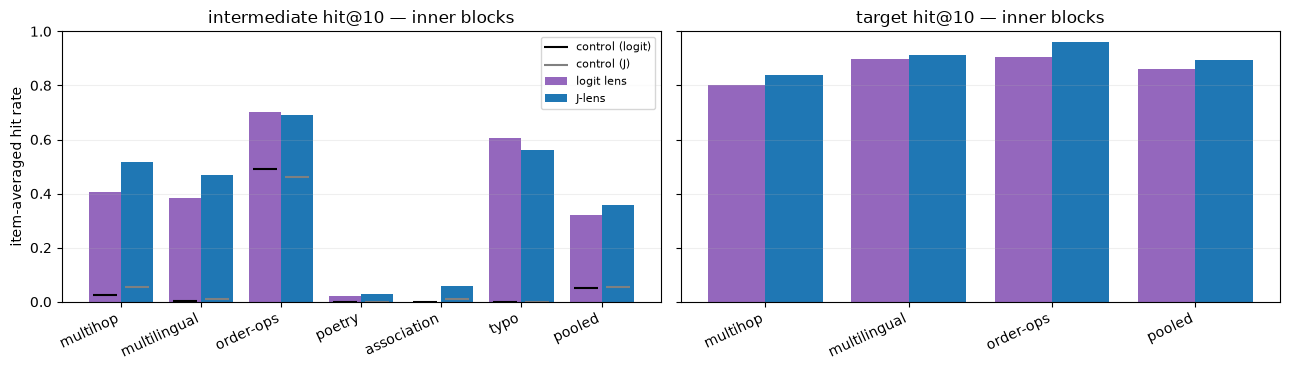

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, name in zip(axes, [f"intermediate hit@{K}", f"target hit@{K}"], strict=True):
    table = bench[name].dropna(subset=["J-lens"])
    x = np.arange(len(table))
    for index, lens_name in enumerate(LENSES):
        ax.bar(x - 0.2 + 0.4 * index, table[lens_name], 0.4, label=lens_name, color=COLORS[lens_name])
    control = bench[f"control hit@{K}"].reindex(table.index)
    if name.startswith("intermediate"):
        ax.scatter(x - 0.2, control["logit lens"], marker="_", s=300, color="k", label="control (logit)")
        ax.scatter(x + 0.2, control["J-lens"], marker="_", s=300, color="gray", label="control (J)")
    ax.set_xticks(x, table.index, rotation=25, ha="right")
    ax.set(title=f"{name} — inner blocks", ylim=(0, 1))
    ax.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("item-averaged hit rate")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()
plt.close(fig)

## 5. Where each lens finds the intermediates: per-layer curves

Fraction of supported intermediates (item-averaged) ranked ≤ K at each block; the last point
is the shared model output. Answer targets are dashed.

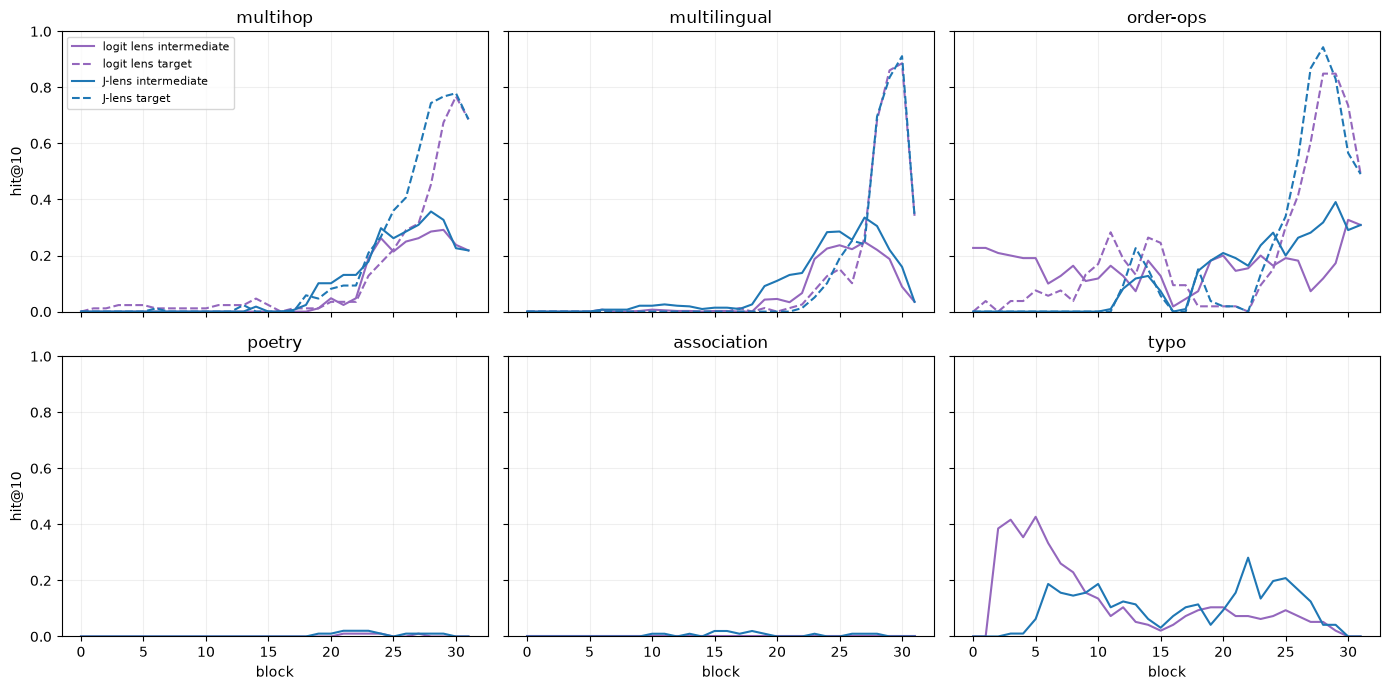

In [11]:
def layer_curve(kind, dataset, lens_name):
    words = all_words[
        all_words["kind"].eq(kind) & all_words["single_token"].eq(True)
        & all_words["dataset"].eq(dataset) & all_words["lens"].eq(lens_name)
    ]
    if words.empty:
        return None
    hits = pd.DataFrame(np.stack(words["ranks"]) <= K, index=words.index)
    return hits.join(words["item"]).groupby("item").mean().mean().to_numpy()


fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, dataset in zip(axes.flat, DATASETS, strict=True):
    for lens_name in LENSES:
        for kind, style in (("intermediate", "-"), ("target", "--")):
            curve = layer_curve(kind, dataset, lens_name)
            if curve is not None:
                ax.plot(curve, style, color=COLORS[lens_name], label=f"{lens_name} {kind}")
    ax.set(title=dataset, ylim=(0, 1))
    ax.grid(alpha=0.2)
for ax in axes[-1]:
    ax.set_xlabel("block")
for ax in axes[:, 0]:
    ax.set_ylabel(f"hit@{K}")
axes[0, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()
plt.close(fig)

## 6. Anthropic Figures 52 / 55 / 56 — adaptations, not reproductions

Reference: [Verbalizable Representations Form a Global Workspace](https://transformer-circuits.pub/2026/workspace/index.html).
Model, lens, spelling protocol and samples differ. **52:** item-weighted intermediate rank
sweep, best over **all blocks including the shared final output** (unlike the inner-only
benchmark above).

lens,J-lens,logit lens
dataset,,
association,0.088,0.039
multihop,0.579,0.513
multilingual,0.452,0.383
order-ops,0.677,0.684
poetry,0.057,0.032
typo,0.548,0.618


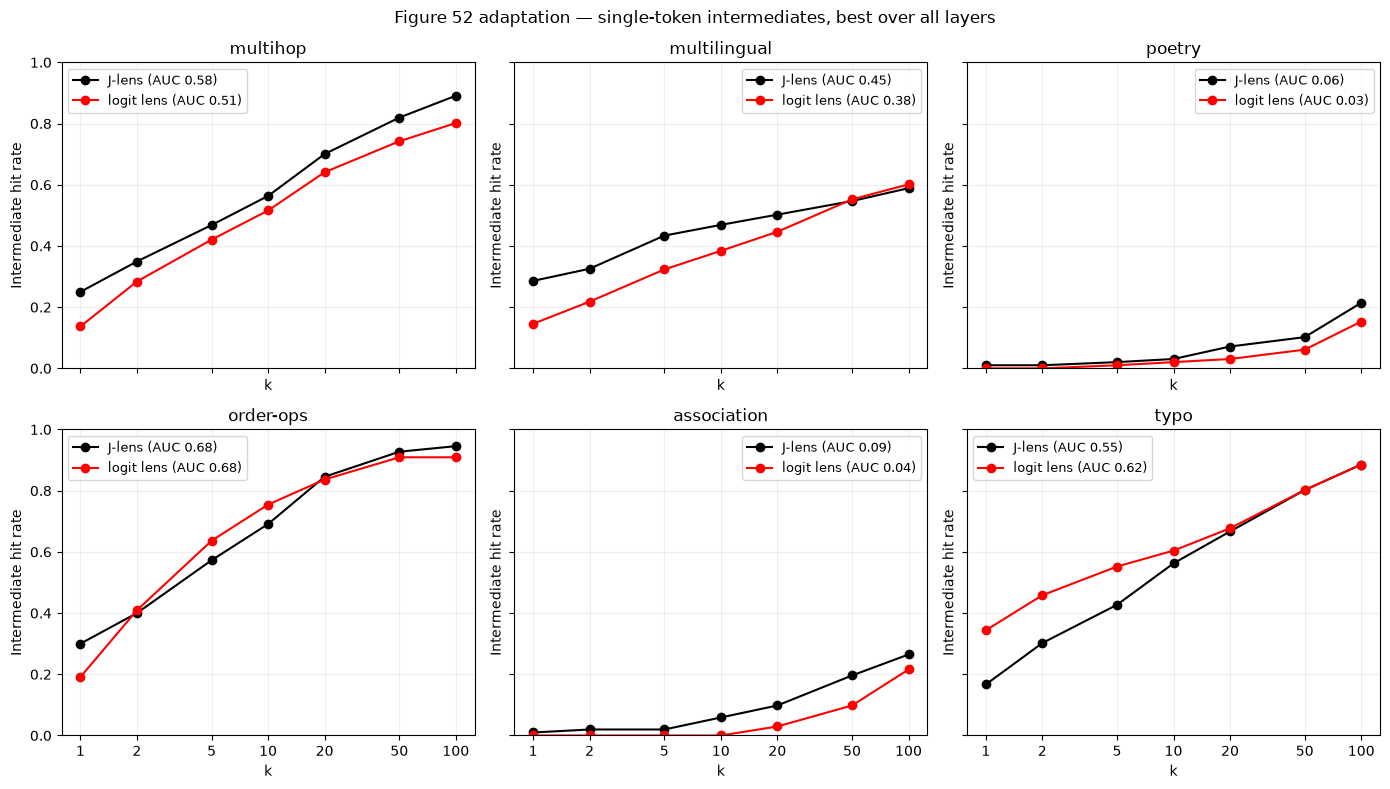

In [12]:
sweep = intermediate_rank_sweep(all_words)
auc52 = sweep.scores.drop_duplicates(["dataset", "lens"]).pivot(index="dataset", columns="lens", values="auc")
display(auc52.style.format(precision=3))
fig52, axes52 = plot_intermediate_sweep(sweep)
plt.show()
plt.close(fig52)

### Held-out diagnostics (Figures 55 / 56)

Whole paragraphs from the WikiText-103 **test** split, 64–128 tokens, the first 256 in corpus
order (section headings skipped; no truncation). Every non-special token position counts.

**55:** token-weighted KL(model ‖ lens), lens entropy (nats) and top-1 agreement with the model
per block. **56:** same-block J vs logit symmetric KL, top-1 agreement, and the vocabulary-mean
cosine between rows of W_U and W_U·J_l (linear head only).

cache hit: held-out-texts-0ef7e43f34d353b9.pkl
256 passages; first: 'Du Fu ( Wade – Giles : Tu Fu ; Chinese : 杜甫 ; 712 – 770 ) was a prominent Chinese poet of the Tang dynasty . Along with Li Bai ( Li Po ) , he is frequently called the greatest of the Chinese poets . H'
cache hit: held-out-74794889df7bb0c4.pkl
cache hit: geometry-5116eb15db7bef90.pkl


,n_texts,n_texts_used,n_tokens,weighting
0,256,256,25536,token


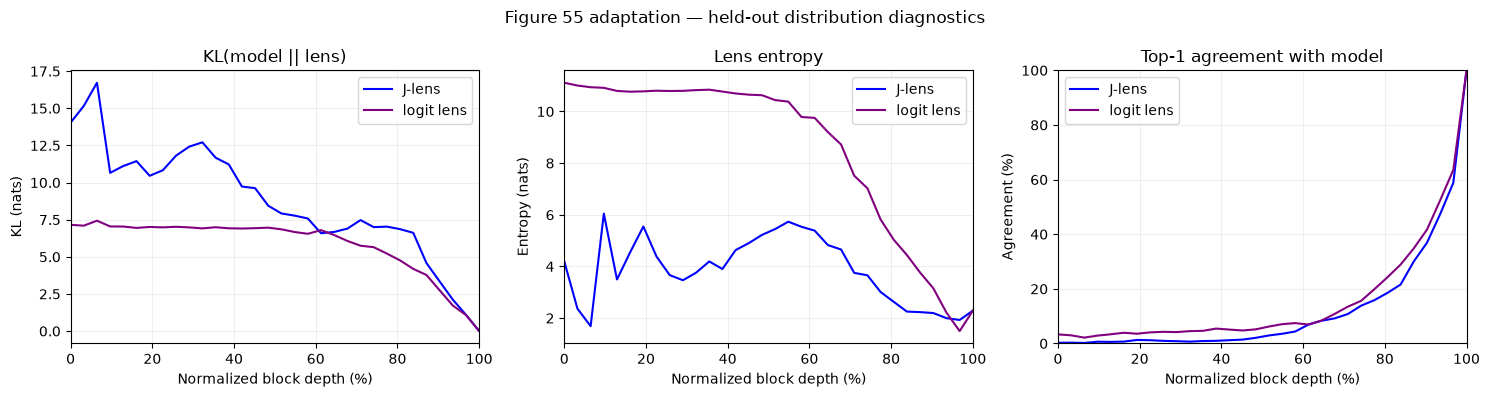

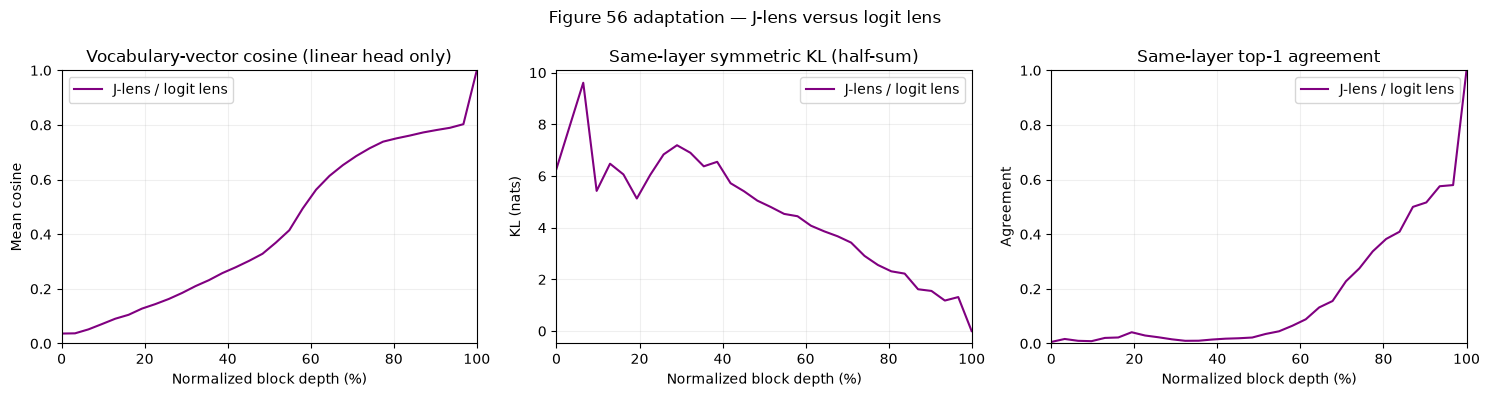

In [13]:
def held_out_texts():
    from datasets import load_dataset

    corpus = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="test")
    texts, low, high = [], *HELD_OUT_TOKENS
    for line in corpus["text"]:
        text = line.strip()
        if not text or text.startswith("="):
            continue
        if low <= len(model.encode_ids(text, max_length=10**6)) <= high:
            texts.append(text)
        if len(texts) == HELD_OUT_N:
            break
    return texts


HELD_OUT_TEXTS = cached("held-out-texts", {"n": HELD_OUT_N, "tokens": HELD_OUT_TOKENS}, held_out_texts)
print(f"{len(HELD_OUT_TEXTS)} passages; first: {HELD_OUT_TEXTS[0][:200]!r}")
held_out = cached(
    "held-out", {"texts": HELD_OUT_TEXTS, "options": HELD_OUT_OPTIONS},
    lambda: evaluate_distributions_batched(model, lens, HELD_OUT_TEXTS, **HELD_OUT_OPTIONS),
)
geometry = cached(
    "geometry", {"vocab_chunk_size": GEOMETRY_VOCAB_CHUNK_SIZE},
    lambda: lens_vector_geometry(model, lens, layers=None, vocab_chunk_size=GEOMETRY_VOCAB_CHUNK_SIZE),
)
display(held_out.layers[["n_texts", "n_texts_used", "n_tokens", "weighting"]].drop_duplicates())
layer_table = held_out.layers.pivot(index="layer", columns="lens",
                                    values=["kl_model_to_lens", "top1_agreement"])
display(layer_table.iloc[::4].style.format(precision=3))
fig55, axes55 = plot_distribution_summary(held_out.layers, n_layers=model.n_layers)
plt.show()
plt.close(fig55)
fig56, axes56 = plot_lens_comparison(held_out.pairs, geometry, n_layers=model.n_layers)
plt.show()
plt.close(fig56)

## 7. What the lenses actually read out (Chinese kept verbatim)

**Script of the top-1 token.** Share of per-block top-1 readouts at the task readout
positions whose text contains a CJK character, for each lens. These tokens are never accepted
as matches for the English labels.

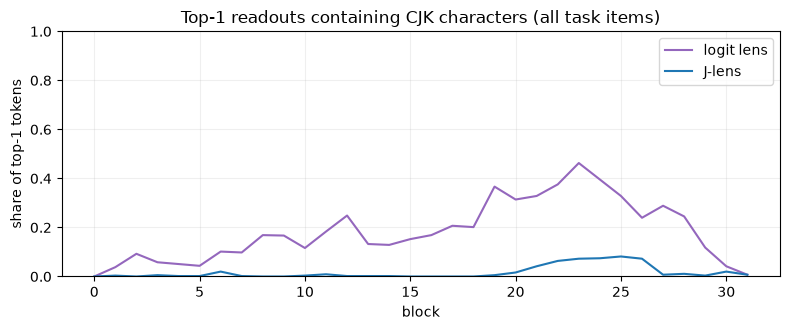

In [14]:
CJK = re.compile(r"[぀-ヿ㐀-䶿一-鿿豈-﫿가-힯]")
cjk = {
    lens_name: np.mean([[bool(CJK.search(t)) for t in row] for row in group["readout_top1"]], axis=0)
    for lens_name, group in items.groupby("lens")
}
fig, ax = plt.subplots(figsize=(8, 3.4))
for lens_name in LENSES:
    ax.plot(cjk[lens_name], color=COLORS[lens_name], label=lens_name)
ax.set(xlabel="block", ylabel="share of top-1 tokens", ylim=(0, 1),
       title="Top-1 readouts containing CJK characters (all task items)")
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)
cjk_by_dataset = pd.DataFrame({
    (dataset, lens_name): [np.mean([any(CJK.search(t) for t in row[:-1]) for row in group["readout_top1"]])]
    for (dataset, lens_name), group in items.groupby(["dataset", "lens"])
}, index=["items with a CJK top-1 at some inner block"]).T.unstack()
display(cjk_by_dataset.style.format(precision=2))

**Per-block top-1 readouts.** For one item per dataset (the first whose intermediate the J-lens
retrieves at K), the top-1 token of each lens at every 2nd block, verbatim. `best rank` gives
the intermediate's best inner rank and block for each lens.

In [15]:
def show_item(dataset, item_name):
    rows = items[items["dataset"].eq(dataset) & items["item"].eq(item_name)].set_index("lens")
    words = all_words[all_words["dataset"].eq(dataset) & all_words["item"].eq(item_name)
                      & all_words["kind"].isin(["intermediate", "target"])]
    head = rows.iloc[0]
    print(f"[{dataset}] {item_name}: {head['prompt'][-160:]!r}")
    print(f"target={head['target']!r}  model top-1={head['model_top1']!r}  correct={head['model_correct']}")
    best = words.pivot_table(index=["kind", "word"], columns="lens", values=["best_rank", "best_layer"],
                             aggfunc="first")
    display(best)
    table = pd.DataFrame({name: rows.loc[name, "readout_top1"] for name in LENSES})
    table.index.name = "block"
    display(table.iloc[::2].T)


def first_retrieved(dataset):
    words = all_words[all_words["dataset"].eq(dataset) & all_words["kind"].eq("intermediate")
                      & all_words["lens"].eq("J-lens") & all_words["single_token"].eq(True)]
    inner_best = words["ranks"].map(lambda r: np.asarray(r)[:-1].min())
    hits = words[inner_best <= K]
    return None if hits.empty else hits["item"].iloc[0]


for dataset in DATASETS:
    name = first_retrieved(dataset)
    if name is not None:
        show_item(dataset, name)

[multihop] spider-legs: 'Fact: The number of legs on the animal that spins webs is '
target='8'  model top-1='8'  correct=True


best_layer            best_rank           
lens                    J-lens logit lens    J-lens logit lens
kind         word                                             
intermediate spider       24.0       24.0       1.0        3.0
target       8            29.0       29.0       1.0        1.0

block,0,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30
logit lens,,,,,,,,,...,___,legs,legs,web,legs,eight,8
J-lens,.,–,，,number,。\,。\,\n,____,____,____,____,legs,spider,legs,eight,8


[multilingual] spanish-opposite-big: 'Lo opuesto de "grande" es "'
target='pequeño'  model top-1='pe'  correct=False


best_layer            best_rank           
lens                      J-lens logit lens    J-lens logit lens
kind         word                                               
intermediate Spanish        13.0       17.0     775.0     2585.0
             big            27.0        6.0     108.0      157.0
             opposite       15.0       12.0    7112.0      101.0
             small          23.0       23.0       1.0        1.0
target       pequeño        29.0       29.0       1.0        1.0

...

best_layer            best_rank           
lens                  J-lens logit lens    J-lens logit lens
kind         word                                           
intermediate dawn       23.0       31.0       6.0      103.0

block,0,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30
logit lens,,\n,入,寒,行,算,unii,侵,uu,纪元,_fast,uu,揉了揉,\n,It,It
J-lens,",",….,.,,,,,——,winter,,,wasn,It,Snow,It,It


[typo] typo-language: 'The course required that every student learn a second langauge'
target=nan  model top-1='.'  correct=None


best_layer            best_rank           
lens                      J-lens logit lens    J-lens logit lens
kind         word                                               
intermediate language        7.0        3.0       1.0        1.0

block,0,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30
logit lens,,西,language,ää,这门,这门,这门,这门,这门,这门,proficiency,proficiency,besides,besides,besides,.
J-lens,–,–,--,--,english,（,（,1,.,.,.,.,besides,besides,.,.


## Conclusions

* **The J-lens is a modestly better retriever of latent words on Qwen3.5-9B, not a uniformly better one.**
  It is significantly ahead on multihop and multilingual, the tasks where the intermediate is a concept the
  model must compute (*spider*, *Spanish*, *small*). On typo and order-ops it is no better than the logit lens.
* **Where the content is.** Intermediates and targets peak late, at blocks 25–29 of 32. The J-lens rises slightly
  earlier on multihop and multilingual (§5). On typo the logit lens finds the corrected word at
  blocks 2–7, which is early token copying of the misspelled input. The J-lens finds it in mid blocks (5–25).
* **Poetry and association stay near zero for both lenses** (≤ 0.06 at K = 10). At the end of line 1 the rhyme
  word is rarely in either top 10. The association concepts (*dawn*, …) are not read out at the last token
  either. Few of these top-1 tokens are Chinese for the J-lens (1–4% of items), so the misses are not a
  translation artefact for the J-lens. For the logit lens, almost every item has some Chinese top-1.
* **Not a next-token predictor.** On held-out WikiText the J-lens agrees with the model's next token *less* often
  than the logit lens and has far higher KL to it in the first ~60% of blocks. It is confident (low entropy) and
  points elsewhere. That is expected for a readout of what a layer *represents*, not of what the model will say.
  The two lenses diverge strongly until ~60% depth: vocabulary cosine < 0.4 and same-block top-1 agreement
  < 10% (Figure 56).
* **"Correct" counts are low by construction (23–33%).** They require the next token to be a whole-token
  spelling of the target, but Qwen often starts the answer with a fragment: `pe` for *pequeño*, `2` for *20*
  (digits are split), or a space or newline. Use the generated-answer notebook for answer accuracy. The
  correct-only panels are therefore small (14–28 items).

**Limitations.** One instruct checkpoint in bf16, one lens fitted by a third party (1000 × 128 WikiText-103
tokens), no chat template. Single-token lexical probe with English labels only. Chinese readouts are kept
verbatim and scored as misses. Controls are another item's words, not a frequency-matched baseline.

**Next.** Add Chinese (and other-language) aliases to the labels and rerun the task pass (~13 min). The
cached table stores ranks only for the English spellings' token IDs. Compare with the
base checkpoint and the Neuronpedia lens, as in `pretrained_lens_summary.ipynb`.

## Explore one prompt (optional)

Set `RUN_SLICE = True`, edit `SLICE_PROMPT` (trailing whitespace matters) and run the cell. The
`jlens.vis` page shows the top tokens of the J-lens at each position × block, Chinese tokens
verbatim; no glossary is applied. The page fetches D3 from jsDelivr on first render.

In [16]:
from jlens.vis import build_page, compute_slice, notebook_iframe

RUN_SLICE = False
SLICE_PROMPT = "The capital of the country where the Eiffel Tower is located is"
SLICE_OPTIONS = dict(top_n=10, max_tracked=256, layer_stride=1, last_n_tokens=32,
                     max_seq_len=512, mask_display=True)
if RUN_SLICE:
    with torch.inference_mode():
        slice_data = compute_slice(model, lens, SLICE_PROMPT, **SLICE_OPTIONS)
    page, _, _ = build_page(slice_data, SLICE_PROMPT, title=f"{MODEL_ID} — pretrained J-lens",
                            description="Full-vocabulary ranks; Chinese tokens untranslated.")
    display(notebook_iframe(page))